In [1]:
import os
import re
import seaborn as sns
import pandas as pd
import numpy as np
from datetime import datetime
import pickle
import matplotlib.pyplot as plt
import hashlib
from collections import defaultdict

In [2]:
base_path = os.getcwd()
file_name = 'experiment_v3_cifar10/exp5_repeat_1/data_QNAS.pkl'
file_name2 = 'experiment_v3_cifar10/exp11_repeat_1/data_QNAS.pkl'
file_path = os.path.join(base_path, file_name)
file_path2 = os.path.join(base_path, file_name2)

In [3]:
def read_data(file_path):
    with open(file_path, 'rb') as f:
        data = pickle.load(f)
    return data

data_2 = read_data(file_path2)

In [4]:
def get_operator_names(config_path: str):
    """
    Parses the log_params_evolution.txt file to get the operator names.
    """
    try:
        with open(config_path, 'r') as f:
            content = f.read()
        match = re.search(r"fn_list:\s*\[([^\]]+)\]", content)
        if match:
            names_str = match.group(1)
            return [name.strip().strip("'\"") for name in names_str.split(',')]
        return None
    except Exception:
        return None

In [5]:
def evolution_time(data):
    date_format = "%Y-%m-%d %H:%M:%S.%f"
    start_time = data[0]['time']
    last_key = list(data.keys())[-1]
    end_time = data[last_key]['time']
    
    start_time = datetime.strptime(start_time, date_format)
    end_time = datetime.strptime(end_time, date_format)
    
    elapsed_time = end_time - start_time
    return elapsed_time

#elapsed_time_1 = evolution_time(data_1)
elapsed_time_2 = evolution_time(data_2)

#print(f"Elapsed time for data 1: {elapsed_time_1}")
print(f"Elapsed time for data 2: {elapsed_time_2}")

Elapsed time for data 2: 7:59:34.142392


In [6]:
def plot_individual(
    data,
    generations,
    individual_idx,
    labels,
    palette=None,
    figsize=(14,6),
    bar_width=0.8
):
    """
    Plots stacked bar charts with small gaps, custom colors, and adjustable figure size.

    Args:
        data (dict): your data dict where data[gen]['net_probs'] is shape (5,20,11)
        generations (list of int): e.g. [0, last_gen]
        individual_idx (int): which individual to plot (0–4)
        labels (list of str]): length-11 list of operator names
        palette (dict): optional mapping label → hex color
        figsize (tuple): (width, height) in inches
        bar_width (float): width of each bar (0.5 → big gaps, 0.9 → small gaps)
    """
    n_gens = len(generations)
    fig, axes = plt.subplots(n_gens, 1, figsize=figsize, sharex=True, sharey=True)
    if n_gens == 1:
        axes = [axes]

    # Build a list of colors in the same order as `labels`
    if palette:
        colors = [palette[label] for label in labels]
    else:
        colors = None  # let pandas choose

    for ax, gen in zip(axes, generations):
        probs = data[gen]['net_probs'][individual_idx]  # (20,11)
        df = pd.DataFrame(probs, columns=labels)

        df.plot(
            kind='bar',
            stacked=True,
            ax=ax,
            width=bar_width,
            edgecolor='white',
            linewidth=0.5,
            color=colors,
            legend=False
        )

        ax.set_ylabel('Probability', fontsize=12)
        ax.set_title(f'Individual {individual_idx} – Generation {gen}', fontsize=12, fontweight='bold')
        ax.set_xticks(np.arange(probs.shape[0]))
        ax.set_xticklabels(np.arange(probs.shape[0]), rotation=0)

    axes[-1].set_xlabel('Network nodes', fontsize=12)

    # One legend on top plot
    axes[0].legend(
        labels,
        bbox_to_anchor=(1.02, 1),
        loc='upper left',
        title='Functions'
    )

    plt.tight_layout()
    plt.show()


In [7]:
config_path = 'experiment_v3_cifar10/exp6_repeat_1/log_params_evolution.txt'
operator_labels = get_operator_names(config_path)

In [8]:
my_palette = {
    'avg_pool_2_2':   '#4C72B0',
    'conv_1_1_32':    '#C44E52',
    'conv_1_1_64':    '#DD8452',
    'conv_3_1_32':    '#E15759',
    'conv_3_1_64':    '#EDC948',
    'conv_3_1_128':   '#4E5F56',
    'conv_3_1_256':   '#55A868',
    'conv_5_1_32':    '#4BACC6',
    'conv_5_1_64':    '#4C72B0',
    'max_pool_2_2':   '#8172B2',
    'no_op':          '#3E2F5B',
}

labels = list(my_palette.keys())

In [9]:
data_2[0]['net_probs'][0][0]

array([0.16666667, 0.04166667, 0.04166667, 0.04166667, 0.04166667,
       0.04166667, 0.04166667, 0.04166667, 0.04166667, 0.16666667,
       0.33333333])

In [10]:
data_2[4]['net_probs'][3][0]

array([0.16666667, 0.04166667, 0.04166667, 0.04166667, 0.04166667,
       0.04166667, 0.04166667, 0.04166667, 0.04166667, 0.16666667,
       0.33333333])

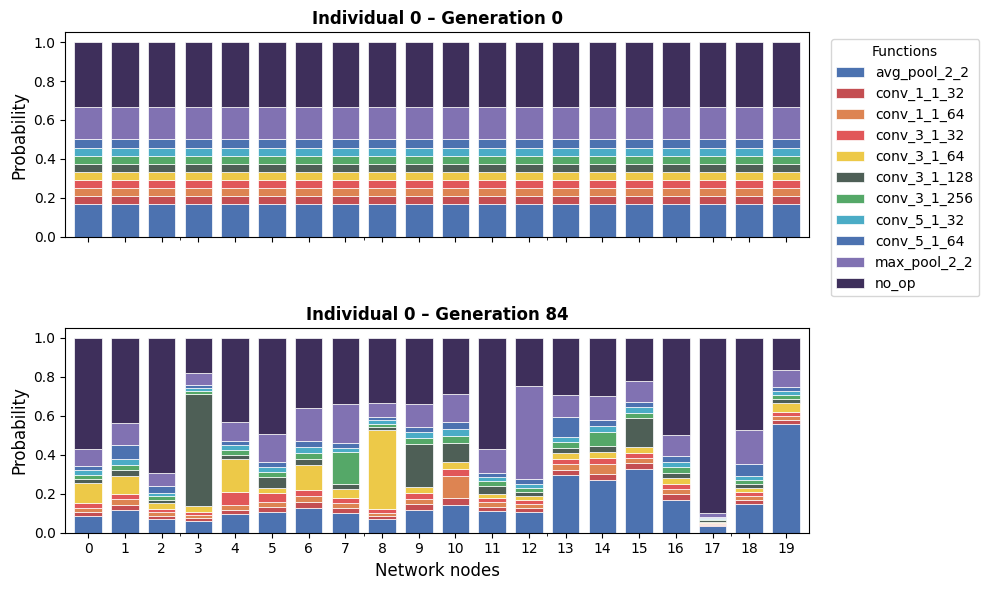

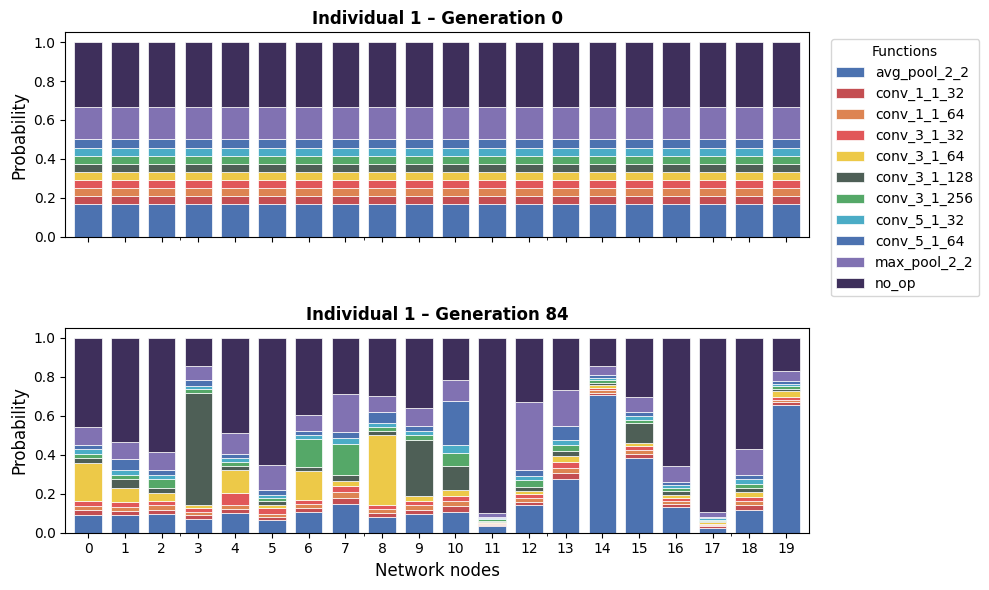

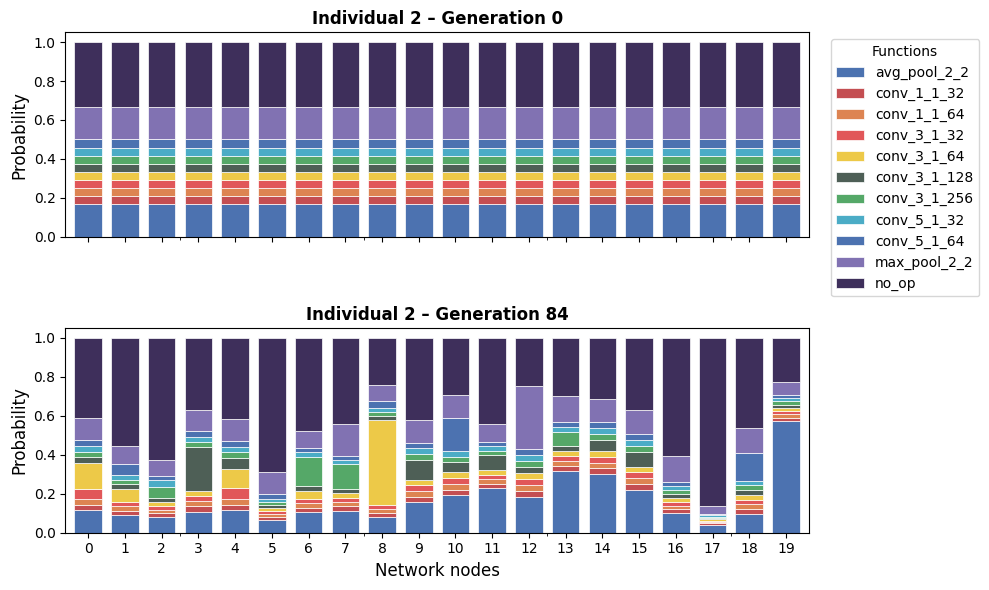

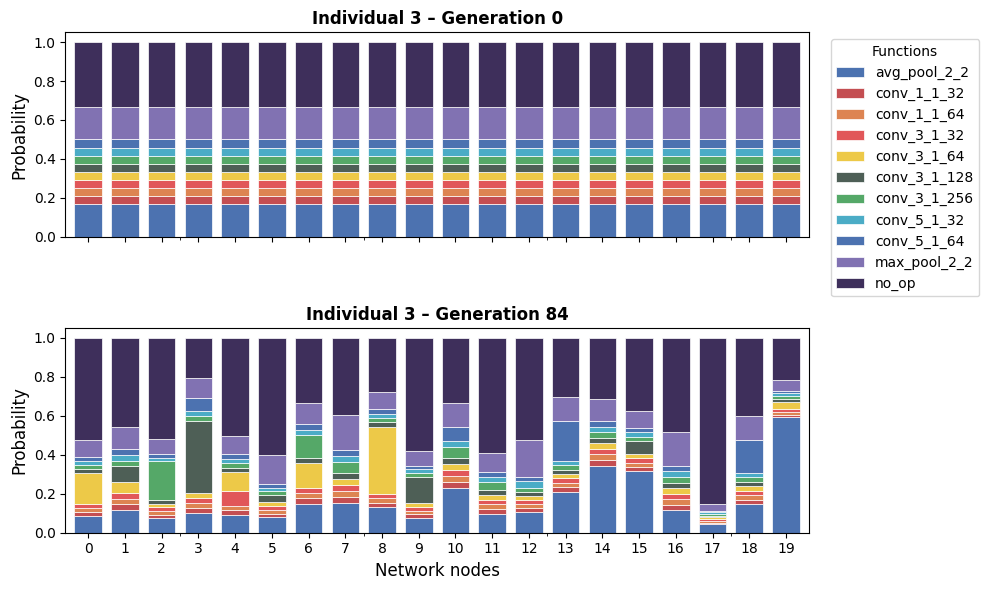

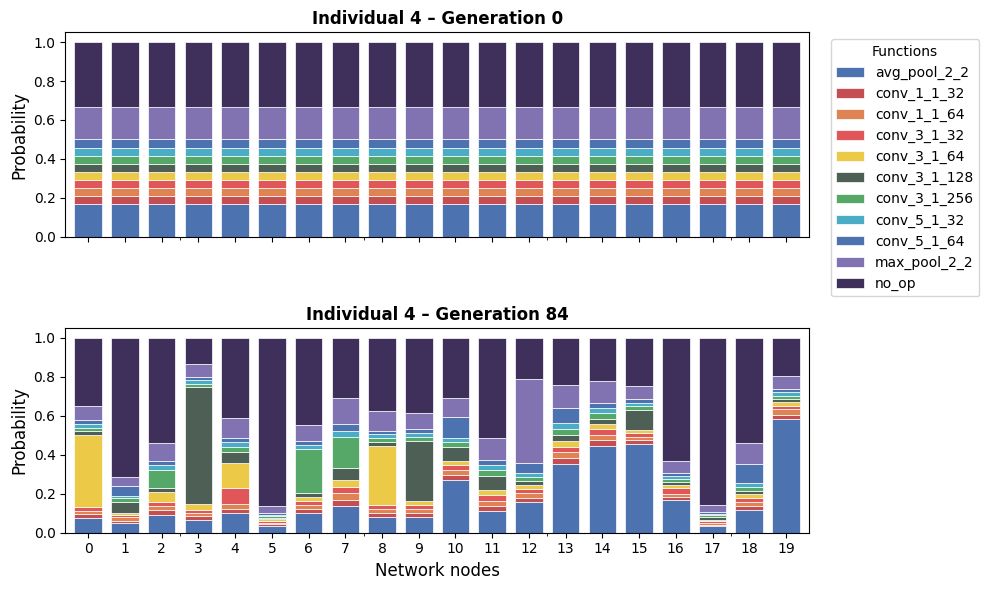

In [11]:
# 2. Pick your two generations (first and last):
data_2 = read_data(file_name2)
gens = [0, max(data_2.keys())]

# 3. Call the plot function, tweaking figsize to taste:

for ind in range(5):
    plot_individual(
        data_2,
        generations=gens,
        individual_idx=ind,
        labels=labels,
        palette=my_palette,
        figsize=(10, 6),   # try wider (e.g. 18×6) or taller (12×10)
        bar_width=0.75     # adjust gap size
    )